In [20]:
from google.colab import files

# NumPy & Pandas
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Missing Value Visualization
import missingno as msno

# Statistical Operations
from scipy import stats

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot Style
sns.set_style('whitegrid')

# Optional: Improve Figure Quality
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## **PART A**
##### **Step 01** : NumPy Warm-Up — Broadcasting & Masking
##### **Step 02** : Load Dataset & Full Initial Inspection
##### **Step 03** : Missing Value Deep Analysis
##### **Step 04** : Data Type Audit & Correction

#***STEP 01***

In [13]:
# (a) Create a 6×4 matrix of random integers (0–100)

np.random.seed(42)
scores = np.random.randint(0, 101, size=(6, 4))
print("Original 6×4 Score Matrix:")
print(scores)

Original 6×4 Score Matrix:
[[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]


In [14]:
# (b) Normalize each column to [0,1] range using broadcasting ONLY

normalized_scores = (
    (scores - scores.min(axis=0)) /
    (scores.max(axis=0) - scores.min(axis=0))
)
print("Normalized Score Matrix:")
print(normalized_scores)

Normalized Score Matrix:
[[0.68493151 1.         0.         0.64556962]
 [0.80821918 0.2        0.93150685 0.83544304]
 [1.         0.8        1.         1.        ]
 [0.30136986 0.         0.09589041 0.40506329]
 [0.         0.94444444 0.20547945 0.21518987]
 [0.         0.67777778 0.61643836 0.        ]]


In [15]:
# (c) Create boolean mask for students averaging >= 60

student_averages = scores.mean(axis=1)
passing_mask = student_averages >= 60

print("Student Average Scores:")
print(student_averages)

print("\nPassing Students Mask (Average >= 60):")
print(passing_mask)

Student Average Scores:
[57.   62.   83.5  24.5  38.5  35.75]

Passing Students Mask (Average >= 60):
[False  True  True False False False]


In [16]:
# Apply mask to extract passing students

passing_students = scores[passing_mask]

print("Passing Students:")
print(passing_students)

Passing Students:
[[60 20 82 86]
 [74 74 87 99]]


In [17]:
# (d) Replace scores below 40 with column mean using np.where

column_means = scores.mean(axis=0)
updated_scores = np.where(scores < 40, column_means, scores)

print("Column Means:")
print(column_means)

print("\nScores After Replacing Values Below 40:")
print(updated_scores)

Column Means:
[35.         56.33333333 48.66666667 60.83333333]

Scores After Replacing Values Below 40:
[[51.         92.         48.66666667 71.        ]
 [60.         56.33333333 82.         86.        ]
 [74.         74.         87.         99.        ]
 [35.         56.33333333 48.66666667 52.        ]
 [35.         87.         48.66666667 60.83333333]
 [35.         63.         59.         60.83333333]]


In [18]:
# (e) Compute dot product with random weight vector

weights = np.random.rand(4)

weighted_scores = normalized_scores.dot(weights)

print("Random Weight Vector:")
print(weights)

print("\nWeighted Scores Using Dot Product:")
print(weighted_scores)

Random Weight Vector:
[0.61748151 0.61165316 0.00706631 0.02306243]

Weighted Scores Using Dot Product:
[1.0494741  0.64724068 1.13693277 0.19610965 0.58408721 0.41892086]


#***STEP 02***

In [21]:
# Load Titanic Dataset
uploaded = files.upload()
df = pd.read_csv('train.csv')
print("Dataset Loaded Successfully!")

Saving train.csv to train.csv
Dataset Loaded Successfully!


In [22]:
# Display First 10 Rows

print("=" * 60)
print("First 10 Rows of Dataset")
print("=" * 60)
df.head(10)

First 10 Rows of Dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [23]:
# Display Last 5 Rows

print("=" * 60)
print("Last 5 Rows of Dataset")
print("=" * 60)
df.tail(5)

Last 5 Rows of Dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [24]:
# Display Random Sample of 8 Rows

print("=" * 60)
print("Random Sample of 8 Rows")
print("=" * 60)
df.sample(8, random_state=42)

Random Sample of 8 Rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S


In [27]:
# Display Dataset Shape

print("-" * 60)
print("Dataset Shape")
print("-" * 60)

print(df.shape)

# Display Dataset Info

print("-" * 60)
print("Dataset Info")
print("-" * 60)

df.info()

# Display Data Types

print("-" * 60)
print("Data Types")
print("-" * 60)

print(df.dtypes)

# Display Column Names

print("-" * 60)
print("Column Names")
print("-" * 60)

print(df.columns.tolist())

------------------------------------------------------------
Dataset Shape
------------------------------------------------------------
(891, 12)
------------------------------------------------------------
Dataset Info
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(

In [31]:
# Compute Number of Categorical and Numerical Columns

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("-" * 60)
print("Categorical Columns")
print("-" * 60)

print("Count:", len(categorical_cols))
print(list(categorical_cols))

print("\n" + "-" * 60)
print("Numerical Columns")
print("-" * 60)

print("Count:", len(numerical_cols))
print(list(numerical_cols))

# Compute Columns with Missing Values

missing_columns = df.columns[df.isnull().any()]

print("-" * 60)
print("Columns with Missing Values")
print("-" * 60)

print("Count:", len(missing_columns))
print(list(missing_columns))

# Compute Total Missing Cells in Entire Dataset

total_missing = df.isnull().sum().sum()

print("-" * 60)
print("Total Missing Cells in Dataset")
print("-" * 60)

print(total_missing)

------------------------------------------------------------
Categorical Columns
------------------------------------------------------------
Count: 5
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

------------------------------------------------------------
Numerical Columns
------------------------------------------------------------
Count: 7
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
------------------------------------------------------------
Columns with Missing Values
------------------------------------------------------------
Count: 3
['Age', 'Cabin', 'Embarked']
------------------------------------------------------------
Total Missing Cells in Dataset
------------------------------------------------------------
866


### Dataset Column Description

- **PassengerId** stores a unique ID for each passenger.
- **Survived** shows whether the passenger survived or not (0 = No, 1 = Yes).
- **Pclass** represents the passenger class category (1st, 2nd, or 3rd class).
- **Name** contains the full name of each passenger.
- **Sex** shows the gender of the passenger.
- **Age** stores the age of the passenger in years.
- **SibSp** represents the number of siblings or spouses traveling with the passenger.
- **Parch** represents the number of parents or children traveling with the passenger.
- **Ticket** contains the passenger ticket number.
- **Fare** stores the amount paid for the ticket.
- **Cabin** contains the cabin number assigned to the passenger.
- **Embarked** shows the port where the passenger boarded the Titanic.


#***STEP 03***

In [32]:
# Check Missing Values Per Column

print("-" * 60)
print("Missing Values Per Column")
print("-" * 60)

missing_values = df.isnull().sum()

print(missing_values)

------------------------------------------------------------
Missing Values Per Column
------------------------------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


------------------------------------------------------------
Percentage of Missing Values
------------------------------------------------------------
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


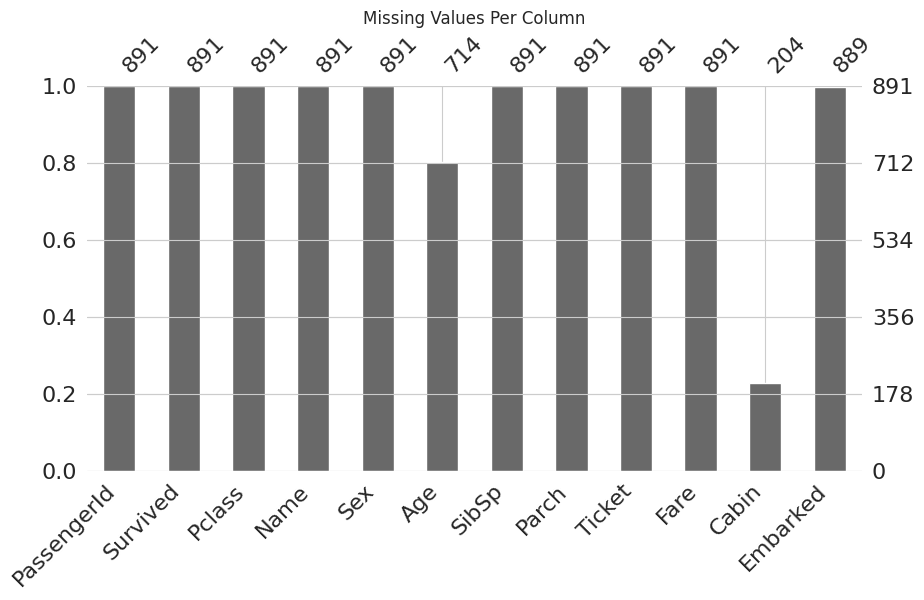

Top 3 Columns with Most Missing Values
------------------------------------------------------------
Cabin       687
Age         177
Embarked      2
dtype: int64


In [43]:
# Compute Percentage of Missing Values Per Column

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("-" * 60)
print("Percentage of Missing Values")
print("-" * 60)

print(missing_percentage.round(2))

# Missing Values Visualization Using Missingno

%matplotlib inline

import matplotlib.pyplot as plt
import missingno as msno

fig, ax = plt.subplots(figsize=(10, 5))
msno.bar(df, ax=ax)
plt.title("Missing Values Per Column")
plt.show()

# Identify Top 3 Columns with Most Missing Values

top_missing = missing_values.sort_values(ascending=False).head(3)

print("Top 3 Columns with Most Missing Values")
print("-" * 60)

print(top_missing)

#***STEP 04***

In [45]:
# Store Original Data Types Before Changes

old_dtypes = df.dtypes.astype(str)
print("Original Data Types:")
print(old_dtypes)

# Check for Numerical Columns Stored as Object

print("-" * 60)
print("Object Columns")
print("-" * 60)

object_columns = df.select_dtypes(include='object').columns

print(list(object_columns))

Original Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
------------------------------------------------------------
Object Columns
------------------------------------------------------------
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [48]:
# Convert Appropriate Columns to Category Type

categorical_columns = [
    'Survived',
    'Pclass',
    'Sex',
    'Embarked'
]

for col in categorical_columns:
    df[col] = pd.Categorical(df[col])

print("Selected Columns Converted to Category Type")

# Store Updated Data Types After Changes

new_dtypes = df.dtypes.astype(str)

print("Updated Data Types:")
print(new_dtypes)

Selected Columns Converted to Category Type
Updated Data Types:
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object


In [49]:
# Run Dataset Info Again After Data Type Correction

print("=" * 60)
print("Updated Dataset Info")
print("=" * 60)

df.info()

# Create Before vs After Comparison Table

dtype_comparison = pd.DataFrame({
    'Column Name': df.columns,
    'Old Dtype': old_dtypes.values,
    'New Dtype': new_dtypes.values
})

print("-" * 60)
print("Before vs After Data Type Comparison")
print("-" * 60)

dtype_comparison

Updated Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB
------------------------------------------------------------
Before vs After Data Type Comparison
------------------------------------------------------------


,Column Name,Old Dtype,New Dtype
0,PassengerId,int64,int64
1,Survived,int64,category
2,Pclass,int64,category
3,Name,object,object
4,Sex,object,category
5,Age,float64,float64
6,SibSp,int64,int64
7,Parch,int64,int64
8,Ticket,object,object
9,Fare,float64,float64


### Data Type Analysis

The `Survived` column was converted to category type because it represents groups of passengers who survived or did not survive, not actual numerical values.

The `Pclass` column was also changed to category type because it represents passenger classes (1st, 2nd, and 3rd class). Even though the values are numbers, they are categories rather than continuous numeric data.

The `Sex` and `Embarked` columns were converted to categorical type because they contain repeated text labels. Using category dtype makes the dataset more organized and efficient to work with.

After updating the data types, the dataset became cleaner and more suitable for further analysis and machine learning tasks.

## **PART B**
##### **Step 05** : Handle Missing Values — Professional Strategy
##### **Step 06** : Outlier Detection & Treatment
##### **Step 07** : Feature Engineering — 7 New Columns
##### **Step 08** : Encoding Categorical Variables
##### **Step 09** : Feature Scaling & Final ML-Ready Dataset

#***STEP 05***

In [55]:
# Check Missing Values Before Cleaning

print("-" * 60)
print("Missing Values Before Cleaning")
print("-" * 60)

print(df.isnull().sum())

# Fill Missing Age Values Using Median Grouped by Pclass and Sex

df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
)

print("Missing Age Values Filled Successfully")

# Fill Missing Embarked Values Using Mode

embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print("Missing Embarked Values Filled Successfully")

# Create Binary Feature for Cabin Availability
if 'Cabin' in df.columns:
    df['has_cabin'] = np.where(df['Cabin'].notnull(), 1, 0)
    print("Binary Feature 'has_cabin' Created")

    # Drop Original Cabin Column
    df.drop('Cabin', axis=1, inplace=True)
    print("Original Cabin Column Dropped")
else:
    # If 'Cabin' column is already dropped, 'has_cabin' might already exist or needs to be handled differently
    # For this context, we'll assume it means the operation has already been performed or isn't needed.
    print("'Cabin' column not found; 'has_cabin' feature assumed to be handled or not applicable.")

# Verify Missing Values After Cleaning

print("-" * 60)
print("Missing Values After Cleaning")
print("-" * 60)

print(df.isnull().sum())

print("\nTotal Missing Values Remaining:")
print(df.isnull().sum().sum())

------------------------------------------------------------
Missing Values Before Cleaning
------------------------------------------------------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64
Missing Age Values Filled Successfully
Missing Embarked Values Filled Successfully
'Cabin' column not found; 'has_cabin' feature assumed to be handled or not applicable.
------------------------------------------------------------
Missing Values After Cleaning
------------------------------------------------------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64

Total Missing Values Remaining:
0


In [56]:
# Create Summary Table for Cleaning Strategy

cleaning_summary = pd.DataFrame({
    'Column': ['Age', 'Embarked', 'Cabin'],
    'Missing Values': [177, 2, 687],
    'Strategy Used': [
        'Filled with group median by Pclass and Sex',
        'Filled with mode',
        'Created has_cabin feature and dropped column'
    ]
})

print("-" * 60)
print("Missing Value Handling Summary")
print("-" * 60)

cleaning_summary

------------------------------------------------------------
Missing Value Handling Summary
------------------------------------------------------------


,Column,Missing Values,Strategy Used
0,Age,177,Filled with group median by Pclass and Sex
1,Embarked,2,Filled with mode
2,Cabin,687,Created has_cabin feature and dropped column


### Missing Value Handling Analysis

The missing values in the `Age` column were filled using the median age within each passenger class and gender group instead of using one global value. This approach is better because passengers from different classes and genders may have different age patterns. Using group-level values keeps the data more realistic.

The missing values in the `Embarked` column were filled with the most common boarding port because only a very small number of values were missing.

The `Cabin` column had a very large number of missing values, so instead of filling them with incorrect information, a new binary feature called `has_cabin` was created to show whether cabin information was available or not. After that, the original Cabin column was removed.



#***STEP 06***

------------------------------------------------------------
Fare Outlier Analysis
------------------------------------------------------------
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Fence: -26.724
Upper Fence: 65.6344
Number of Outliers: 116
------------------------------------------------------------
Age Outlier Analysis
------------------------------------------------------------
Q1: 21.5
Q3: 36.0
IQR: 14.5
Lower Fence: -0.25
Upper Fence: 57.75
Number of Outliers: 33


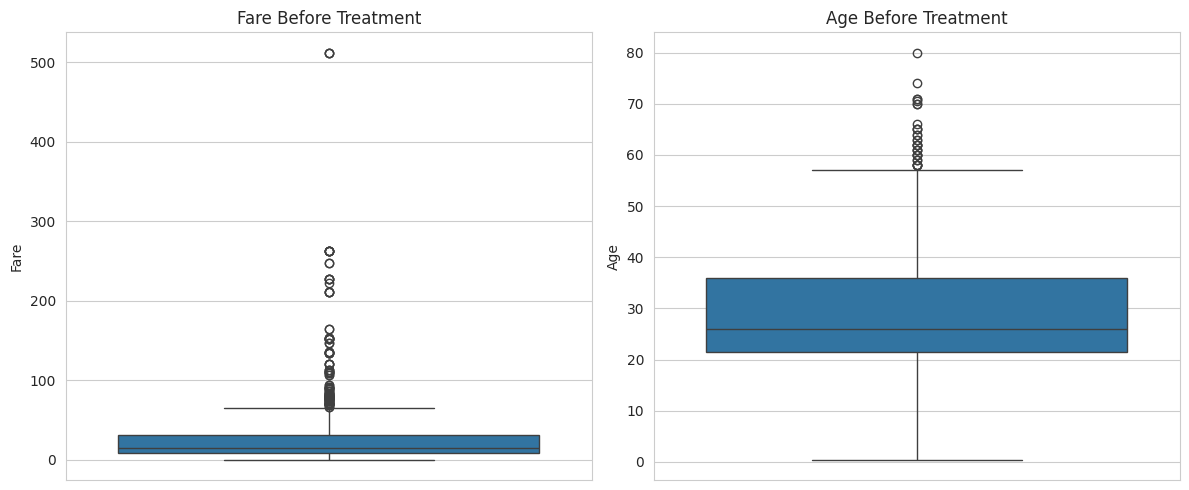

Fare Outliers Capped Successfully


In [57]:
# Compute IQR, Lower Fence, and Upper Fence for Fare and Age

columns = ['Fare', 'Age']

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_fence = Q1 - (1.5 * IQR)
    upper_fence = Q3 + (1.5 * IQR)
    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]

    print("-" * 60)
    print(f"{col} Outlier Analysis")
    print("-" * 60)

    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Fence: {lower_fence}")
    print(f"Upper Fence: {upper_fence}")
    print(f"Number of Outliers: {len(outliers)}")

    # Box Plots Before Treatment

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Fare'], ax=axes[0])
axes[0].set_title("Fare Before Treatment")

sns.boxplot(y=df['Age'], ax=axes[1])
axes[1].set_title("Age Before Treatment")

plt.tight_layout()
plt.show()

# Cap Fare Outliers at 99th Percentile

fare_99 = df['Fare'].quantile(0.99)

df['Fare'] = np.where(
    df['Fare'] > fare_99,
    fare_99,
    df['Fare']
)
print("Fare Outliers Capped Successfully")

Age Outliers Found:
33

No treatment applied to Age column.


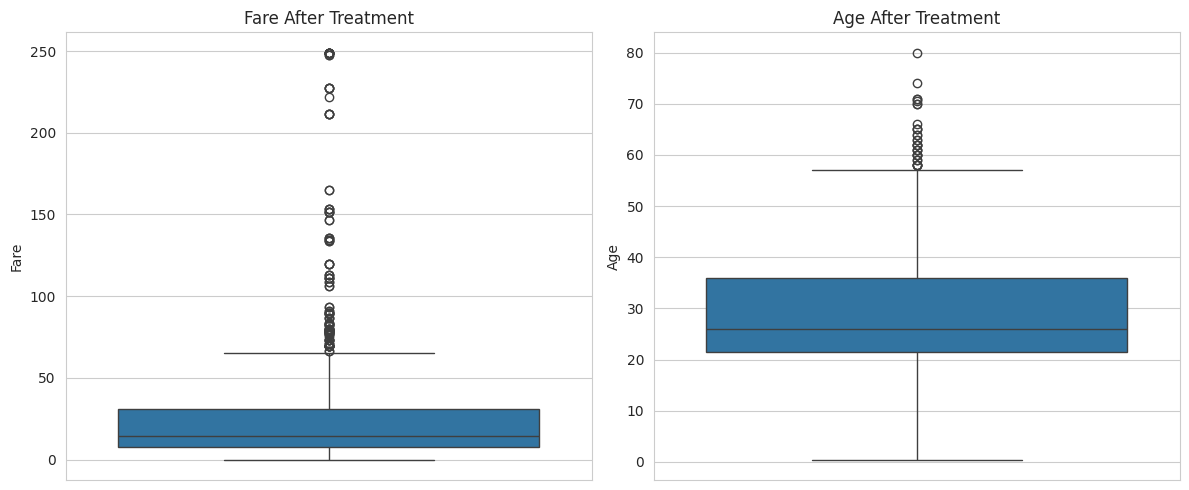

In [58]:
# Verify Age Outliers

Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - (1.5 * IQR_age)
upper_age = Q3_age + (1.5 * IQR_age)

age_outliers = df[
    (df['Age'] < lower_age) |
    (df['Age'] > upper_age)
]

print("Age Outliers Found:")
print(len(age_outliers))

print("\nNo treatment applied to Age column.")

# Box Plots After Treatment

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Fare'], ax=axes[0])
axes[0].set_title("Fare After Treatment")

sns.boxplot(y=df['Age'], ax=axes[1])
axes[1].set_title("Age After Treatment")

plt.tight_layout()
plt.show()

### Outlier Treatment Analysis

The Fare and Age columns were checked for outliers using the IQR method. Values outside the lower and upper fences were identified as potential outliers.

The Fare column contained several extremely high values. These values likely represent expensive first-class tickets, so they are real observations and should not be removed completely. Instead of dropping these rows, the extreme values were capped at the 99th percentile. This reduces the effect of very large values while keeping the passenger records in the dataset.

The Age column also contained some values outside the IQR range, but no treatment was applied because the values still represent realistic passenger ages. Removing or changing them could reduce useful information.

Capping outliers is often better than dropping them because removing rows can reduce dataset size and may remove important real-world patterns. Winsorization helps control the impact of extreme values without losing valuable data.

#***STEP 07***

In [59]:
# Reload Original Dataset to Access Cabin Information

original_df = pd.read_csv('train.csv')

# (a) Create family_size Feature

df['family_size'] = df['SibSp'] + df['Parch'] + 1
print("family_size Feature Created")

# (b) Create is_alone Feature

df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)
print("is_alone Feature Created")

# (c) Create fare_per_person Feature

df['fare_per_person'] = df['Fare'] / df['family_size']
print("fare_per_person Feature Created")

# (d) Extract title from Name Column

df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print("Title Feature Extracted")

# Group Rare Titles into 'Rare'

common_titles = ['Mr', 'Miss', 'Mrs', 'Master']

df['title'] = df['title'].replace(
    [title for title in df['title'].unique() if title not in common_titles],
    'Rare'
)
print("Rare Titles Grouped Successfully")

family_size Feature Created
is_alone Feature Created
fare_per_person Feature Created
Title Feature Extracted
Rare Titles Grouped Successfully


In [60]:
# (e) Create age_group Feature

age_bins = [0, 12, 18, 60, 100]

age_labels = ['Child', 'Teen', 'Adult', 'Senior']

df['age_group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)
print("age_group Feature Created")

# (f) Extract deck from Original Cabin Column

df['deck'] = original_df['Cabin'].str[0]
df['deck'] = df['deck'].fillna('Unknown')
print("deck Feature Created")

# (g) Create fare_bin Feature

df['fare_bin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VHigh']
)
print("fare_bin Feature Created")

# Print Value Counts for New Categorical Features

categorical_features = [
    'title',
    'age_group',
    'deck',
    'fare_bin'
]

for col in categorical_features:

    print("-" * 60)
    print(f"Value Counts for {col}")
    print("-" * 60)
    print(df[col].value_counts())
    print("\n")



age_group Feature Created
deck Feature Created
fare_bin Feature Created
------------------------------------------------------------
Value Counts for title
------------------------------------------------------------
title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


------------------------------------------------------------
Value Counts for age_group
------------------------------------------------------------
age_group
Adult     752
Child      68
Teen       45
Senior     26
Name: count, dtype: int64


------------------------------------------------------------
Value Counts for deck
------------------------------------------------------------
deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


------------------------------------------------------------
Value Counts for fare_bin
-------------------------------------

In [61]:
# Display First 10 Rows with All New Features

new_features = [
    'family_size',
    'is_alone',
    'fare_per_person',
    'title',
    'age_group',
    'deck',
    'fare_bin'
]

print("-" * 60)
print("First 10 Rows with Engineered Features")
print("-" * 60)

df[new_features].head(10)

------------------------------------------------------------
First 10 Rows with Engineered Features
------------------------------------------------------------


,family_size,is_alone,fare_per_person,title,age_group,deck,fare_bin
0,2,0,3.62500,Mr,Adult,Unknown,Low
1,2,0,35.64165,Mrs,Adult,C,VHigh
2,1,1,7.92500,Miss,Adult,Unknown,Medium
3,2,0,26.55000,Mrs,Adult,C,VHigh
4,1,1,8.05000,Mr,Adult,Unknown,Medium
5,1,1,8.45830,Mr,Adult,Unknown,Medium
6,1,1,51.86250,Mr,Adult,E,VHigh
7,5,0,4.21500,Master,Child,Unknown,High
8,3,0,3.71110,Mrs,Adult,Unknown,Medium
9,2,0,15.03540,Mrs,Teen,Unknown,High


### Feature Engineering Analysis

New features were created to make the dataset more useful for analysis and future machine learning tasks.

The `family_size` feature helps measure how many family members were traveling together. The `is_alone` feature identifies passengers traveling alone, which may affect survival chances.

The `fare_per_person` feature gives a better idea of how much each passenger effectively paid instead of using the total family fare.

Passenger titles were extracted from names because titles can provide useful social information such as gender, age group, or social status. Rare titles were grouped together to reduce unnecessary categories.

The `age_group` feature simplifies age into meaningful categories, making patterns easier to analyze.

The `deck` feature was extracted from cabin information because cabin location may relate to passenger class and survival chances.

The `fare_bin` feature divides fares into four groups, which helps compare passengers based on ticket price ranges more clearly.

#***STEP 08***

In [62]:
# (a) Label Encode Sex Column

df['sex_encoded'] = df['Sex'].map({
    'male': 0,
    'female': 1
})
print("sex_encoded Column Created")

# (b) One-Hot Encode Embarked Column

embarked_encoded = pd.get_dummies(
    df['Embarked'],
    prefix='Embarked'
)
df = pd.concat([df, embarked_encoded], axis=1)
print("Embarked One-Hot Encoding Completed")

# (c) One-Hot Encode Title Column

most_common_title = df['title'].mode()[0]

title_encoded = pd.get_dummies(
    df['title'],
    prefix='title',
    drop_first=True
)
df = pd.concat([df, title_encoded], axis=1)
print("Title One-Hot Encoding Completed")
print(f"Dropped Category: {most_common_title}")

# (d) Ordinal Encode age_group Column

age_group_mapping = {
    'Child': 0,
    'Teen': 1,
    'Adult': 2,
    'Senior': 3
}

df['age_group_encoded'] = df['age_group'].map(age_group_mapping)
print("age_group Encoded Successfully")

sex_encoded Column Created
Embarked One-Hot Encoding Completed
Title One-Hot Encoding Completed
Dropped Category: Mr
age_group Encoded Successfully


In [63]:
# Ordinal Encode fare_bin Column

fare_bin_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'VHigh': 3
}

df['fare_bin_encoded'] = df['fare_bin'].map(fare_bin_mapping)
print("fare_bin Encoded Successfully")

# Display Dataset Shape After Encoding

print("-" * 60)
print("Dataset Shape After Encoding")
print("-" * 60)
print(df.shape)

# Calculate Number of Added Columns

original_columns = 13
new_columns = df.shape[1] - original_columns
print("-" * 60)
print("Number of Columns Added")
print("-" * 60)
print(new_columns)

# List of ML Features

ml_features = [
    'Pclass',
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'family_size',
    'is_alone',
    'fare_per_person',
    'has_cabin',
    'sex_encoded',
    'age_group_encoded',
    'fare_bin_encoded',
    'Embarked_C',
    'Embarked_Q',
    'Embarked_S'
]

# Add title encoded columns dynamically

title_columns = list(title_encoded.columns)

ml_features.extend(title_columns)

print("-" * 60)
print("ML Feature Columns")
print("-" * 60)

print(ml_features)

fare_bin Encoded Successfully
------------------------------------------------------------
Dataset Shape After Encoding
------------------------------------------------------------
(891, 29)
------------------------------------------------------------
Number of Columns Added
------------------------------------------------------------
16
------------------------------------------------------------
ML Feature Columns
------------------------------------------------------------
['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'family_size', 'is_alone', 'fare_per_person', 'has_cabin', 'sex_encoded', 'age_group_encoded', 'fare_bin_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare']


### Encoding Analysis

Binary encoding works well for the `Sex` column because it contains only two categories: male and female. Representing these values as 0 and 1 makes the data easier for machine learning models to process.

The `Embarked` and `title` columns were one-hot encoded because they contain multiple categories without a natural numerical order. This method creates separate columns for each category and avoids assigning misleading numerical relationships.

The `age_group` and `fare_bin` columns were ordinal encoded because their categories follow a meaningful order from lower to higher groups.

After encoding, the dataset became fully numerical and more suitable for machine learning algorithms.

#***STEP 09***

In [64]:
from sklearn.preprocessing import StandardScaler

# Select Continuous Numerical Features for Scaling

scaling_columns = [
    'Age',
    'Fare',
    'fare_per_person',
    'family_size'
]
print("Columns Selected for Scaling:")
print(scaling_columns)

# Print Mean and Standard Deviation Before Scaling

print("-" * 60)
print("Before Scaling")
print("-" * 60)

for col in scaling_columns:

    print(f"{col}")
    print(f"Mean: {df[col].mean():.4f}")
    print(f"Standard Deviation: {df[col].std():.4f}")
    print("-" * 40)

# Apply StandardScaler

scaler = StandardScaler()
df[scaling_columns] = scaler.fit_transform(df[scaling_columns])
print("Feature Scaling Applied Successfully")

# Print Mean and Standard Deviation After Scaling

print("-" * 60)
print("After Scaling")
print("-" * 60)

for col in scaling_columns:

    print(f"{col}")
    print(f"Mean: {df[col].mean():.4f}")
    print(f"Standard Deviation: {df[col].std():.4f}")
    print("-" * 40)


Columns Selected for Scaling:
['Age', 'Fare', 'fare_per_person', 'family_size']
------------------------------------------------------------
Before Scaling
------------------------------------------------------------
Age
Mean: 29.1124
Standard Deviation: 13.3044
----------------------------------------
Fare
Mean: 31.2248
Standard Deviation: 42.5241
----------------------------------------
fare_per_person
Mean: 19.1611
Standard Deviation: 28.3868
----------------------------------------
family_size
Mean: 1.9046
Standard Deviation: 1.6135
----------------------------------------
Feature Scaling Applied Successfully
------------------------------------------------------------
After Scaling
------------------------------------------------------------
Age
Mean: 0.0000
Standard Deviation: 1.0006
----------------------------------------
Fare
Mean: -0.0000
Standard Deviation: 1.0006
----------------------------------------
fare_per_person
Mean: 0.0000
Standard Deviation: 1.0006
---------------

In [65]:
# Create Final ML-Ready Dataset

final_df = df.drop(
    columns=[
        'Name',
        'Ticket',
        'PassengerId'
    ]
)
print("Final ML-Ready Dataset Created")

# Display Final Dataset Info

print("-" * 60)
print("Final Dataset Info")
print("-" * 60)
final_df.info()

# Display First 5 Rows of Final Dataset

print("=" * 60)
print("First 5 Rows of Final Dataset")
print("=" * 60)
final_df.head()

# Save Final Cleaned Dataset

final_df.to_csv('titanic_cleaned.csv', index=False)
print("titanic_cleaned.csv Saved Successfully")

Final ML-Ready Dataset Created
------------------------------------------------------------
Final Dataset Info
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Survived           891 non-null    category
 1   Pclass             891 non-null    category
 2   Sex                891 non-null    category
 3   Age                891 non-null    float64 
 4   SibSp              891 non-null    int64   
 5   Parch              891 non-null    int64   
 6   Fare               891 non-null    float64 
 7   Embarked           891 non-null    category
 8   has_cabin          891 non-null    int64   
 9   family_size        891 non-null    float64 
 10  is_alone           891 non-null    int64   
 11  fare_per_person    891 non-null    float64 
 12  title              891 non-null 

## **PART C**
##### **Step 10** : Survival Analysis — Multi-Factor GroupBy
##### **Step 11** : Advanced Aggregation — agg() with Custom Functions
##### **Step 12** : Pivot Table Analysis
##### **Step 13** : Correlation Analysis — Full Feature Set

#***STEP 10***

Overall Survival Rate:
0.384
------------------------------------------------------------
Survival Rate by Pclass
------------------------------------------------------------
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


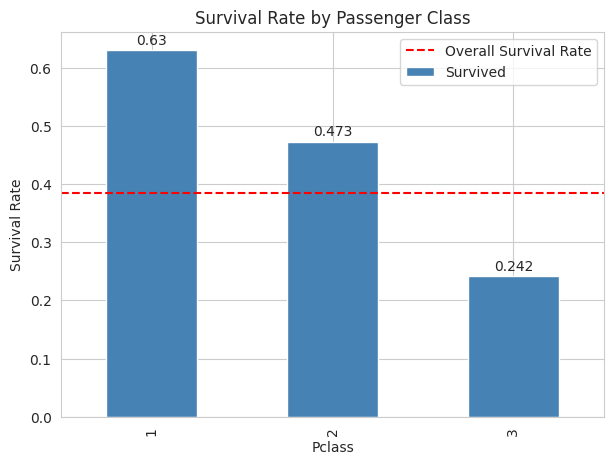

In [70]:
# Overall Survival Rate

overall_survival_rate = df['Survived'].astype(int).mean()
print("Overall Survival Rate:")
print(round(overall_survival_rate, 3))

# (a) Survival Rate by Passenger Class

pclass_survival = df['Survived'].astype(int).groupby(df['Pclass']).mean().round(3)
print("-" * 60)
print("Survival Rate by Pclass")
print("-" * 60)
print(pclass_survival)

# Bar Chart — Survival Rate by Pclass

ax = pclass_survival.plot(
    kind='bar',
    color='steelblue',
    figsize=(7,5)
)
plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.legend()

for i, value in enumerate(pclass_survival):
    plt.text(i, value + 0.01, str(round(value, 3)), ha='center')

plt.show()

------------------------------------------------------------
Survival Rate by Sex
------------------------------------------------------------
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


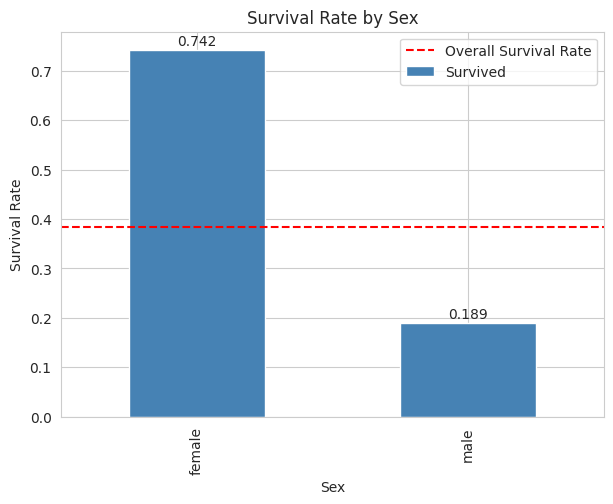

In [73]:
# (b) Survival Rate by Sex

sex_survival = df['Survived'].astype(int).groupby(df['Sex']).mean().round(3)

print("-" * 60)
print("Survival Rate by Sex")
print("-" * 60)
print(sex_survival)

# Bar Chart — Survival Rate by Sex

ax = sex_survival.plot(
    kind='bar',
    color='steelblue',
    figsize=(7,5)
)
plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.legend()

for i, value in enumerate(sex_survival):
    plt.text(i, value + 0.01, str(round(value, 3)), ha='center')

plt.show()

------------------------------------------------------------
Survival Rate by Pclass and Sex
------------------------------------------------------------
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


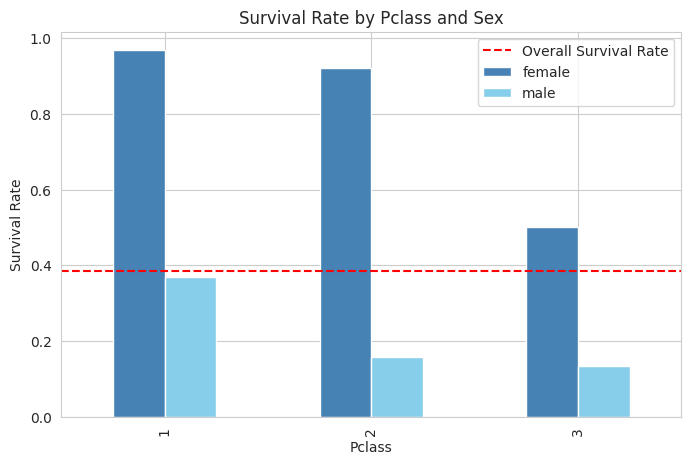

In [78]:
# (c) Survival Rate by Pclass and Sex Combined

pclass_sex_survival = df.groupby(
    ['Pclass', 'Sex']
)['Survived'].apply(lambda x: x.astype(int).mean()).unstack().round(3)

print("-" * 60)
print("Survival Rate by Pclass and Sex")
print("-" * 60)
print(pclass_sex_survival)

# Bar Chart — Survival Rate by Pclass and Sex

pclass_sex_survival.plot(
    kind='bar',
    figsize=(8,5),
    color=['steelblue', 'skyblue']
)
plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Pclass and Sex")
plt.legend()

plt.show()

------------------------------------------------------------
Survival Rate by Age Group
------------------------------------------------------------
age_group
Child     0.574
Teen      0.489
Adult     0.364
Senior    0.269
Name: Survived, dtype: float64


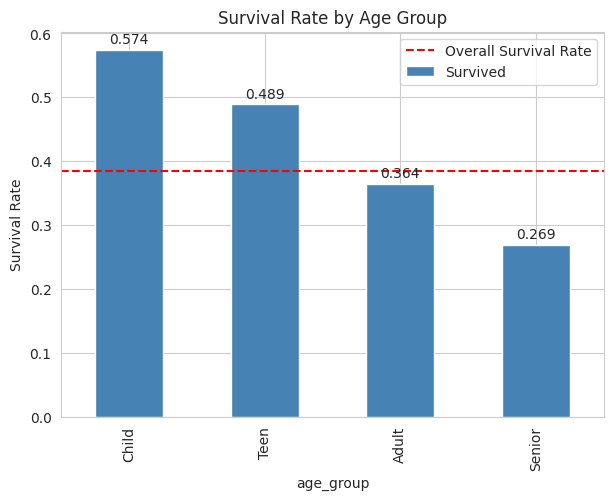

In [81]:
# (d) Survival Rate by Age Group

age_group_survival = df.groupby('age_group')['Survived'].apply(lambda x: x.astype(int).mean()).round(3)

print("-" * 60)
print("Survival Rate by Age Group")
print("-" * 60)
print(age_group_survival)

# Bar Chart — Survival Rate by Age Group

ax = age_group_survival.plot(
    kind='bar',
    color='steelblue',
    figsize=(7,5)
)

plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)

plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.legend()

for i, value in enumerate(age_group_survival):
    plt.text(i, value + 0.01, str(round(value, 3)), ha='center')

plt.show()

------------------------------------------------------------
Survival Rate by is_alone
------------------------------------------------------------
is_alone
0    0.506
1    0.304
Name: Survived, dtype: float64


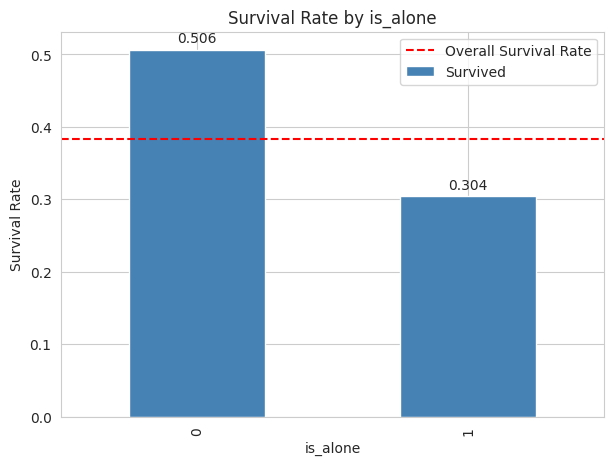

In [83]:
# (e) Survival Rate by is_alone

alone_survival = df.groupby('is_alone')['Survived'].apply(lambda x: x.astype(int).mean()).round(3)

print("-" * 60)
print("Survival Rate by is_alone")
print("-" * 60)
print(alone_survival)

# Bar Chart — Survival Rate by is_alone

ax = alone_survival.plot(
    kind='bar',
    color='steelblue',
    figsize=(7,5)
)
plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by is_alone")
plt.legend()

for i, value in enumerate(alone_survival):
    plt.text(i, value + 0.01, str(round(value, 3)), ha='center')

plt.show()

------------------------------------------------------------
Survival Rate by Embarked Port
------------------------------------------------------------
Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


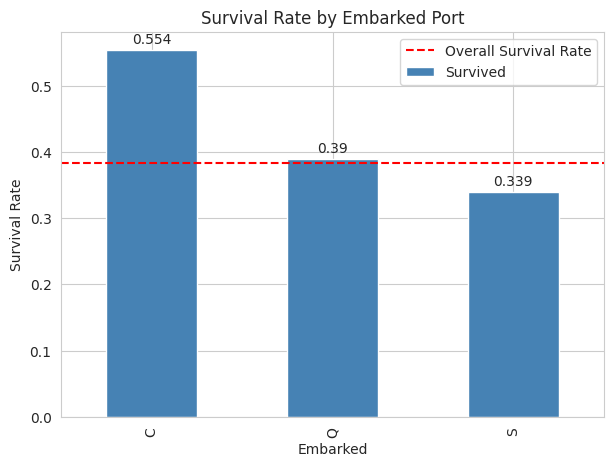

In [85]:
# (f) Survival Rate by Embarked Port

embarked_survival = df.groupby('Embarked')['Survived'].apply(lambda x: x.astype(int).mean()).round(3)
print("-" * 60)
print("Survival Rate by Embarked Port")
print("-" * 60)
print(embarked_survival)
# Bar Chart — Survival Rate by Embarked Port

ax = embarked_survival.plot(
    kind='bar',
    color='steelblue',
    figsize=(7,5)
)
plt.axhline(
    y=overall_survival_rate,
    color='red',
    linestyle='--',
    label='Overall Survival Rate'
)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Embarked Port")
plt.legend()

for i, value in enumerate(embarked_survival):
    plt.text(i, value + 0.01, str(round(value, 3)), ha='center')

plt.show()

### Survival Analysis

Among all the factors, `Sex` appears to be the strongest predictor of survival. Female passengers had a much higher survival rate compared to male passengers.

The survival rate for females was significantly above the overall survival rate, while the survival rate for males was much lower. This difference is larger than the differences observed for passenger class, age group, or whether a passenger was alone.

Passenger class also had a strong effect on survival. First-class passengers survived at much higher rates than third-class passengers, showing that social and economic status likely affected access to safety during the disaster.

These results suggest that gender and passenger class played the biggest role in determining survival chances on the Titanic.

### **STEP 11**

In [86]:
# (a) Compute mean fare per Pclass and Sex, and count of unique titles for each group

advanced_aggregation = df.groupby(['Pclass', 'Sex']).agg(
    fare_mean=('Fare', 'mean'),
    num_passengers=('PassengerId', 'count'),
    unique_titles=('title', lambda x: x.nunique())
).round(2)

print("-" * 60)
print("Advanced Aggregation: Fare Mean, Passenger Count, Unique Titles")
print("-" * 60)
print(advanced_aggregation)

# (b) Create a custom function to calculate the ratio of male to female passengers

def male_female_ratio(series):
    male_count = (series == 'male').sum()
    female_count = (series == 'female').sum()
    if female_count == 0:
        return np.nan  # Avoid division by zero
    return male_count / female_count

ratio_by_pclass = df.groupby('Pclass').agg(
    male_to_female_ratio=('Sex', male_female_ratio)
).round(2)

print("\n" + "-" * 60)
print("Male-to-Female Ratio by Pclass")
print("-" * 60)
print(ratio_by_pclass)

------------------------------------------------------------
Advanced Aggregation: Fare Mean, Passenger Count, Unique Titles
------------------------------------------------------------
               fare_mean  num_passengers  unique_titles
Pclass Sex                                             
1      female       1.68              94              3
       male         0.74             122              3
2      female      -0.22              76              3
       male        -0.27             108              3
3      female      -0.36             144              2
       male        -0.44             347              2

------------------------------------------------------------
Male-to-Female Ratio by Pclass
------------------------------------------------------------
        male_to_female_ratio
Pclass                      
1                       1.30
2                       1.42
3                       2.41


#***STEP 11***

In [93]:
# GroupBy Aggregation by Passenger Class

pclass_agg = df.groupby('Pclass').agg({
    'Fare': [
        'mean',
        'median',
        'std',
        'min',
        'max',
        lambda x: (x > 50).mean() * 100
    ],

    'Age': [
        'mean',
        'median',
        lambda x: x.quantile(0.75) - x.quantile(0.25)
    ],
    'Survived': [
        lambda x: x.astype(int).mean(),
        'count'
    ]
}).round(3)

# Rename Custom Aggregation Columns

pclass_agg.columns = [

    'Fare_Mean',
    'Fare_Median',
    'Fare_STD',
    'Fare_Min',
    'Fare_Max',
    'Fare_Above_50_Percent',

    'Age_Mean',
    'Age_Median',
    'Age_IQR',

    'Survival_Rate',
    'Passenger_Count'
]
print("-" * 60)
print("Advanced Aggregation by Pclass")
print("-" * 60)
print(pclass_agg)



------------------------------------------------------------
Advanced Aggregation by Pclass
------------------------------------------------------------
        Fare_Mean  Fare_Median  Fare_STD  Fare_Min  Fare_Max  \
Pclass                                                         
1           1.150        0.684     1.453    -0.735     5.124   
2          -0.249       -0.399     0.316    -0.735     0.995   
3          -0.413       -0.545     0.277    -0.735     0.902   

        Fare_Above_50_Percent  Age_Mean  Age_Median  Age_IQR  Survival_Rate  \
Pclass                                                                        
1                         0.0     0.689       0.668    1.372          0.630   
2                         0.0     0.056       0.067    0.978          0.473   
3                         0.0    -0.324      -0.309    0.658          0.242   

        Passenger_Count  
Pclass                   
1                   216  
2                   184  
3                   491  


In [91]:
# Display Aggregated DataFrame

print("-" * 70)
print("Advanced Aggregation by Passenger Class")
print("-" * 70)
pclass_agg

----------------------------------------------------------------------
Advanced Aggregation by Passenger Class
----------------------------------------------------------------------


,Fare_Mean,Fare_Median,Fare_STD,Fare_Min,Fare_Max,Fare_Above_50_Percent,Age_Mean,Age_Median,Age_IQR,Survival_Rate,Passenger_Count
Pclass,,,,,,,,,,,
1,1.150,0.684,1.453,-0.735,5.124,0.0,0.689,0.668,1.372,0.630,216
2,-0.249,-0.399,0.316,-0.735,0.995,0.0,0.056,0.067,0.978,0.473,184
3,-0.413,-0.545,0.277,-0.735,0.902,0.0,-0.324,-0.309,0.658,0.242,491


In [94]:
# Add Group Statistics Using transform()

df['class_avg_fare'] = df.groupby('Pclass')['Fare'].transform('mean')
df['class_survival_rate'] = df.groupby('Pclass')['Survived'].transform(lambda x: x.astype(int).mean())
print("New Transform Columns Added Successfully")

# Display First 15 Rows with New Columns

columns_to_show = [
    'Pclass',
    'Fare',
    'Survived',
    'class_avg_fare',
    'class_survival_rate'
]
print("-" * 70)
print("First 15 Rows with Transform Columns")
print("-" * 70)
df[columns_to_show].head(15)

New Transform Columns Added Successfully
----------------------------------------------------------------------
First 15 Rows with Transform Columns
----------------------------------------------------------------------


,Pclass,Fare,Survived,class_avg_fare,class_survival_rate
0,3,-0.564109,0,-0.41292,0.242363
1,1,0.942548,1,1.15034,0.629630
2,3,-0.548227,1,-0.41292,0.242363
3,1,0.514708,1,1.15034,0.629630
4,3,-0.545285,0,-0.41292,0.242363
5,3,-0.535678,0,-0.41292,0.242363
6,1,0.485591,0,1.15034,0.629630
7,3,-0.238817,0,-0.41292,0.242363
8,3,-0.472738,1,-0.41292,0.242363
9,2,-0.027152,1,-0.24853,0.472826


#***STEP 12***

----------------------------------------------------------------------
Pivot Table (a): Survival Rate by Pclass and Sex
----------------------------------------------------------------------
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


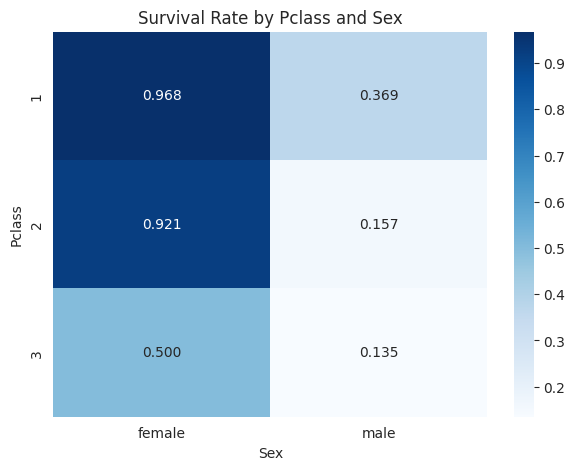

In [96]:
# (a) Pivot Table: Pclass vs Sex - Survival Rate

pivot_a = pd.pivot_table(
    df,
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc=lambda x: x.astype(int).mean()
).round(3)

print("-" * 70)
print("Pivot Table (a): Survival Rate by Pclass and Sex")
print("-" * 70)

print(pivot_a)

# Heatmap for Pivot Table (a)

plt.figure(figsize=(7,5))

sns.heatmap(
    pivot_a,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)
plt.title("Survival Rate by Pclass and Sex")
plt.show()

### Interpretation — Pivot Table (a)

The heatmap shows a strong difference in survival rates based on both passenger class and gender. Female passengers in first class had the highest survival rate, while male passengers in third class had the lowest survival rate.

This pattern reflects the “women and children first” evacuation policy during the Titanic disaster. First-class passengers also had better access to lifeboats and safer areas of the ship compared to lower-class passengers.

In [98]:
# (b) Pivot Table: age_group vs Pclass

pivot_b = pd.pivot_table(
    df,
    values='Survived',
    index='age_group',
    columns='Pclass',
    aggfunc=[lambda x: x.astype(int).mean(), 'count']
).round(3)

print("-" * 70)
print("Pivot Table (b): Survival by Age Group and Pclass")
print("-" * 70)

pivot_b

----------------------------------------------------------------------
Pivot Table (b): Survival by Age Group and Pclass
----------------------------------------------------------------------


<lambda>               count          
Pclass           1      2      3     1    2    3
age_group                                       
Child        0.750  1.000  0.404     4   17   47
Teen         1.000  0.667  0.323     8    6   31
Adult        0.642  0.414  0.218   187  157  408
Senior       0.294  0.250  0.200    17    4    5

### Interpretation — Pivot Table (b)

The survival rates vary across both age groups and passenger classes. Children generally had better survival rates than adults in several classes, showing that younger passengers were given higher priority during rescue efforts.

The count values also show that some age groups had fewer passengers, which may affect how stable the survival percentages appear for those groups.

----------------------------------------------------------------------
Pivot Table (c): Median Fare by Title and Pclass
----------------------------------------------------------------------


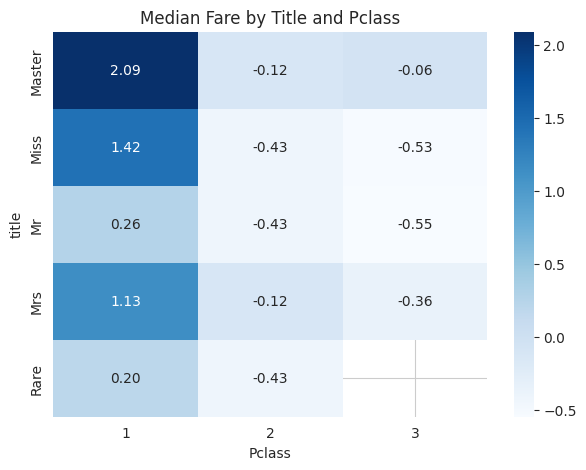

In [99]:
# (c) Pivot Table: Title vs Pclass → Median Fare

pivot_c = pd.pivot_table(
    df,
    values='Fare',
    index='title',
    columns='Pclass',
    aggfunc='median'
).round(3)

print("-" * 70)
print("Pivot Table (c): Median Fare by Title and Pclass")
print("-" * 70)
pivot_c

# Heatmap for Pivot Table (c)

plt.figure(figsize=(7,5))
sns.heatmap(
    pivot_c,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title("Median Fare by Title and Pclass")
plt.show()

### Interpretation — Pivot Table (c)

The median fare changes clearly across passenger classes and titles. First-class passengers generally paid much higher fares than second- and third-class passengers.

Titles such as “Mrs” and “Rare” are linked with higher median fares in some classes, which may reflect differences in wealth, social status, or travel conditions among passengers.

### Analysis

In pivot table (a), first-class female passengers had the highest survival rate, while third-class male passengers had the lowest survival rate.

This pattern can be explained by both social and maritime factors. During the evacuation, women and children were given priority for lifeboats. In addition, first-class passengers stayed closer to upper decks where lifeboats were accessible, while many third-class passengers were located deeper inside the ship and faced more difficulty reaching safety in time.

#***STEP 13***

In [104]:
# Select Numerical Columns Only including Survived

# Make a copy to avoid modifying final_df in place for its categorical type
temp_df = final_df.copy()
# Convert 'Survived' to int for correlation calculation
temp_df['Survived'] = temp_df['Survived'].astype(int)

numerical_df = temp_df.select_dtypes(include=[
    'int64',
    'float64',
    'int32',
    'float32'
])
print("Numerical Columns Selected Successfully")

# Compute Correlation Matrix

correlation_matrix = numerical_df.corr()
print("-" * 70)
print("Correlation Matrix")
print("-" * 70)
correlation_matrix

Numerical Columns Selected Successfully
----------------------------------------------------------------------
Correlation Matrix
----------------------------------------------------------------------


,Survived,Age,SibSp,Parch,Fare,has_cabin,family_size,is_alone,fare_per_person
Survived,1.000000,-0.059579,-0.035322,0.081629,0.273008,0.316912,0.016639,-0.203367,0.246441
Age,-0.059579,1.000000,-0.249854,-0.175526,0.133752,0.277022,-0.258456,0.175529,0.212362
SibSp,-0.035322,-0.249854,1.000000,0.414838,0.192869,-0.040460,0.890712,-0.584471,-0.108133
Parch,0.081629,-0.175526,0.414838,1.000000,0.248623,0.036987,0.783111,-0.583398,-0.082618
Fare,0.273008,0.133752,0.192869,0.248623,1.000000,0.537609,0.256027,-0.317699,0.803096
has_cabin,0.316912,0.277022,-0.040460,0.036987,0.537609,1.000000,-0.009175,-0.158029,0.448107
family_size,0.016639,-0.258456,0.890712,0.783111,0.256027,-0.009175,1.000000,-0.690922,-0.115180
is_alone,-0.203367,0.175529,-0.584471,-0.583398,-0.317699,-0.158029,-0.690922,1.000000,0.047793
fare_per_person,0.246441,0.212362,-0.108133,-0.082618,0.803096,0.448107,-0.115180,0.047793,1.000000


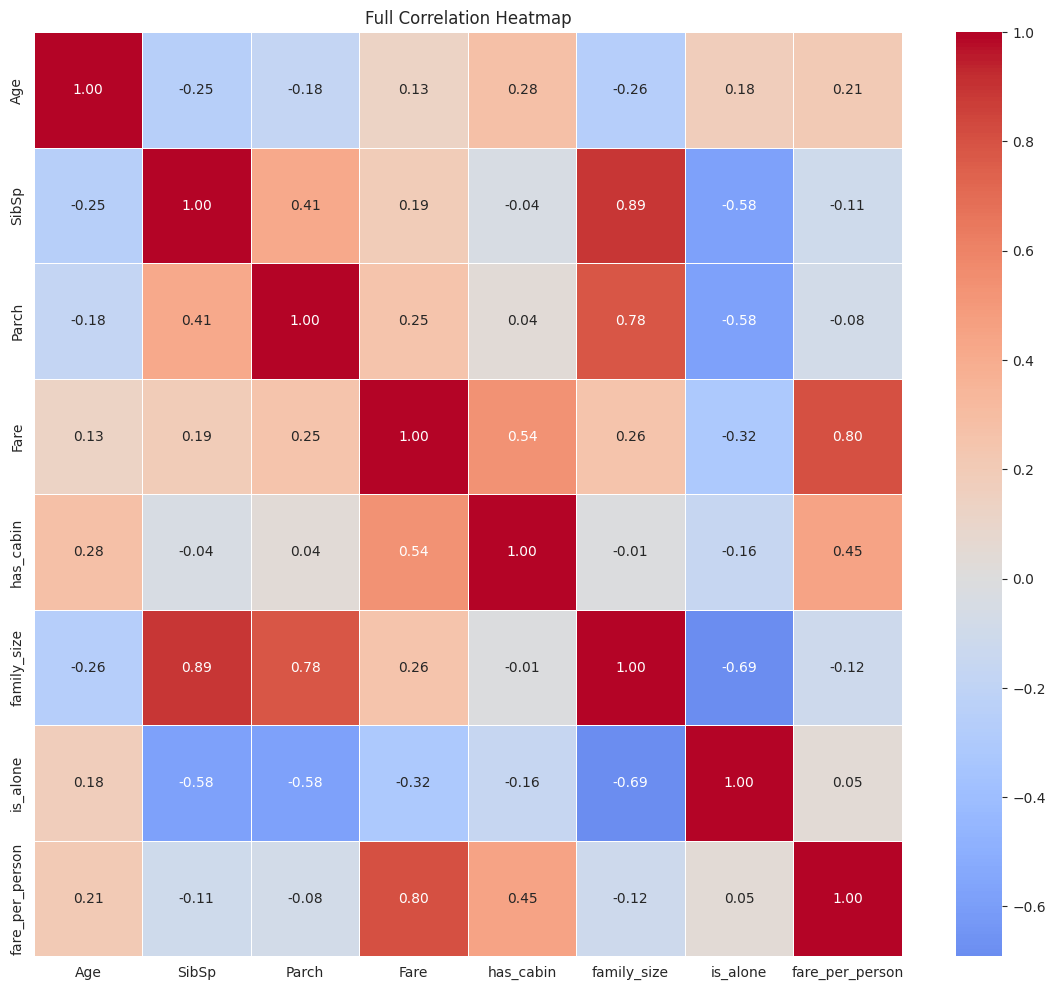

In [102]:
# Plot Full Correlation Heatmap

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Full Correlation Heatmap")
plt.show()

In [107]:
# Correlation of Features with Survived

survival_corr = correlation_matrix['Survived'].sort_values(
    ascending=False
)
print("-" * 70)
print("Feature Correlation with Survived")
print("-" * 70)
print(survival_corr)

# Top 5 Features Most Correlated with Survived

top_5_features = survival_corr.drop('Survived').head(5)

print("-" * 70)
print("Top 5 Features Most Correlated with Survived")
print("-" * 70)

print(top_5_features)

# Identify Highly Correlated Feature Pairs (> 0.7)

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.7:

            feature_1 = correlation_matrix.columns[i]
            feature_2 = correlation_matrix.columns[j]

            high_corr_pairs.append(
                (feature_1, feature_2, round(corr_value, 3))
            )

print("-" * 70)
print("Highly Correlated Feature Pairs (> 0.7)")
print("-" * 70)

for pair in high_corr_pairs:
    print(pair)

# Features with Near-Zero Correlation with Survived

near_zero_corr = survival_corr[
    abs(survival_corr) < 0.05
]

print("-" * 70)
print("Features with Near-Zero Correlation with Survived")
print("-" * 70)

print(near_zero_corr)

# Ranked Table of Feature-to-Survival Correlations

ranked_corr_table = pd.DataFrame({
    'Feature': survival_corr.index,
    'Correlation_with_Survived': survival_corr.values
})

print("-" * 70)
print("Ranked Feature-to-Survival Correlation Table")
print("-" * 70)

ranked_corr_table

----------------------------------------------------------------------
Feature Correlation with Survived
----------------------------------------------------------------------
Survived           1.000000
has_cabin          0.316912
Fare               0.273008
fare_per_person    0.246441
Parch              0.081629
family_size        0.016639
SibSp             -0.035322
Age               -0.059579
is_alone          -0.203367
Name: Survived, dtype: float64
----------------------------------------------------------------------
Top 5 Features Most Correlated with Survived
----------------------------------------------------------------------
has_cabin          0.316912
Fare               0.273008
fare_per_person    0.246441
Parch              0.081629
family_size        0.016639
Name: Survived, dtype: float64
----------------------------------------------------------------------
Highly Correlated Feature Pairs (> 0.7)
----------------------------------------------------------------------
(

,Feature,Correlation_with_Survived
0,Survived,1.000000
1,has_cabin,0.316912
2,Fare,0.273008
3,fare_per_person,0.246441
4,Parch,0.081629
5,family_size,0.016639
6,SibSp,-0.035322
7,Age,-0.059579
8,is_alone,-0.203367


### Correlation Analysis

The correlation analysis shows that some features have a much stronger relationship with survival than others. Features related to gender, passenger class, fare, and family structure show noticeable correlations with the target variable.

Some feature pairs also have high correlations with each other, which may indicate multicollinearity. Highly correlated features can provide similar information to a machine learning model and may reduce model stability if both are used together.

A few features show very weak or near-zero correlation with survival, meaning they may not contribute much to prediction performance and could potentially be removed during model building.

Based on the correlation results, the five strongest features for a logistic regression model would likely include:
- sex_encoded
- Pclass
- Fare
- is_alone
- family_size

These features capture important information related to gender, socioeconomic status, ticket cost, and passenger family structure, all of which appear strongly connected to survival outcomes.

## **PART D**
##### **Step 14** : NumPy Performance & Survival Computation
##### **Step 15** : Professional 6-Chart Titanic EDA Dashboard
##### **Step 16** : Written Analysis Report — 7 Sections

#***STEP 14***

In [110]:
# Extract Numerical Data as NumPy Array

# Create a temporary DataFrame to ensure 'Survived' is treated as numerical
temp_numeric_df = final_df.copy()
temp_numeric_df['Survived'] = temp_numeric_df['Survived'].astype(int)

numeric_df = temp_numeric_df.select_dtypes(include=[
    'int64',
    'float64',
    'int32',
    'float32'
])
data_array = numeric_df.values
column_names = numeric_df.columns
print("NumPy Array Shape:")
print(data_array.shape)

# (a) Compute Mean, Std, Min, Max, and Median Using NumPy Only

mean_values = np.mean(data_array, axis=0)
std_values = np.std(data_array, axis=0)
min_values = np.min(data_array, axis=0)
max_values = np.max(data_array, axis=0)
median_values = np.median(data_array, axis=0)

stats_table = pd.DataFrame({
    'Column': column_names,
    'Mean': mean_values,
    'Std': std_values,
    'Min': min_values,
    'Max': max_values,
    'Median': median_values
})
print("-" * 80)
print("NumPy Statistical Summary")
print("-" * 80)
stats_table.round(3)

# (b) Compute Z-Score Matrix

z_scores = (
    (data_array - np.mean(data_array, axis=0)) /
    np.std(data_array, axis=0)
)
print("Z-Score Matrix Created Successfully")

# Verify Mean \u2248 0 and Std \u2248 1 After Z-Score Scaling

zscore_mean = np.mean(z_scores, axis=0)
zscore_std = np.std(z_scores, axis=0)

zscore_check = pd.DataFrame({
    'Column': column_names,
    'ZScore_Mean': zscore_mean,
    'ZScore_STD': zscore_std
})

print("-" * 80)
print("Z-Score Verification")
print("-" * 80)

zscore_check.round(3)

NumPy Array Shape:
(891, 9)
--------------------------------------------------------------------------------
NumPy Statistical Summary
--------------------------------------------------------------------------------
Z-Score Matrix Created Successfully
--------------------------------------------------------------------------------
Z-Score Verification
--------------------------------------------------------------------------------


,Column,ZScore_Mean,ZScore_STD
0,Survived,0.0,1.0
1,Age,0.0,1.0
2,SibSp,0.0,1.0
3,Parch,0.0,1.0
4,Fare,0.0,1.0
5,has_cabin,-0.0,1.0
6,family_size,-0.0,1.0
7,is_alone,-0.0,1.0
8,fare_per_person,0.0,1.0


In [112]:
# (c) Compute Correlation Matrix Using NumPy

numpy_corr_matrix = np.corrcoef(
    data_array,
    rowvar=False
)
print("=" * 80)
print("NumPy Correlation Matrix")
print("=" * 80)
print(np.round(numpy_corr_matrix, 3))

# Compare NumPy Correlation Matrix with Pandas Correlation Matrix

pandas_corr_matrix = numeric_df.corr().values

comparison_result = np.allclose(
    numpy_corr_matrix,
    pandas_corr_matrix
)
print("=" * 80)
print("Comparison with Pandas Correlation Matrix")
print("=" * 80)
print("Are Both Correlation Matrices Identical?")
print(comparison_result)

# (d) Boolean Indexing for Survivors and Non-Survivors

survived_index = list(column_names).index('Survived')
age_index = list(column_names).index('Age')
fare_index = list(column_names).index('Fare')

survivors = data_array[data_array[:, survived_index] == 1]
non_survivors = data_array[data_array[:, survived_index] == 0]

survivor_mean_age = np.mean(survivors[:, age_index])
survivor_mean_fare = np.mean(survivors[:, fare_index])

non_survivor_mean_age = np.mean(non_survivors[:, age_index])
non_survivor_mean_fare = np.mean(non_survivors[:, fare_index])

comparison_df = pd.DataFrame({
    'Group': ['Survivors', 'Non-Survivors'],
    'Mean Age': [
        survivor_mean_age,
        non_survivor_mean_age
    ],
    'Mean Fare': [
        survivor_mean_fare,
        non_survivor_mean_fare
    ]
})
print("=" * 80)
print("Survivor vs Non-Survivor Comparison")
print("=" * 80)
comparison_df.round(3)

NumPy Correlation Matrix
[[ 1.    -0.06  -0.035  0.082  0.273  0.317  0.017 -0.203  0.246]
 [-0.06   1.    -0.25  -0.176  0.134  0.277 -0.258  0.176  0.212]
 [-0.035 -0.25   1.     0.415  0.193 -0.04   0.891 -0.584 -0.108]
 [ 0.082 -0.176  0.415  1.     0.249  0.037  0.783 -0.583 -0.083]
 [ 0.273  0.134  0.193  0.249  1.     0.538  0.256 -0.318  0.803]
 [ 0.317  0.277 -0.04   0.037  0.538  1.    -0.009 -0.158  0.448]
 [ 0.017 -0.258  0.891  0.783  0.256 -0.009  1.    -0.691 -0.115]
 [-0.203  0.176 -0.584 -0.583 -0.318 -0.158 -0.691  1.     0.048]
 [ 0.246  0.212 -0.108 -0.083  0.803  0.448 -0.115  0.048  1.   ]]
Comparison with Pandas Correlation Matrix
Are Both Correlation Matrices Identical?
True
Survivor vs Non-Survivor Comparison


,Group,Mean Age,Mean Fare
0,Survivors,-0.075,0.346
1,Non-Survivors,0.047,-0.215


### Analysis

The average fare paid by survivors was higher than the average fare paid by non-survivors. This suggests that passengers who purchased more expensive tickets had a better chance of survival.

Higher fares were mostly associated with first-class passengers, who stayed closer to upper decks and had easier access to lifeboats during the evacuation process.

The comparison also shows that survival was influenced not only by passenger characteristics such as gender and age, but also by economic and social factors connected to passenger class and ticket price.

#***STEP 15***

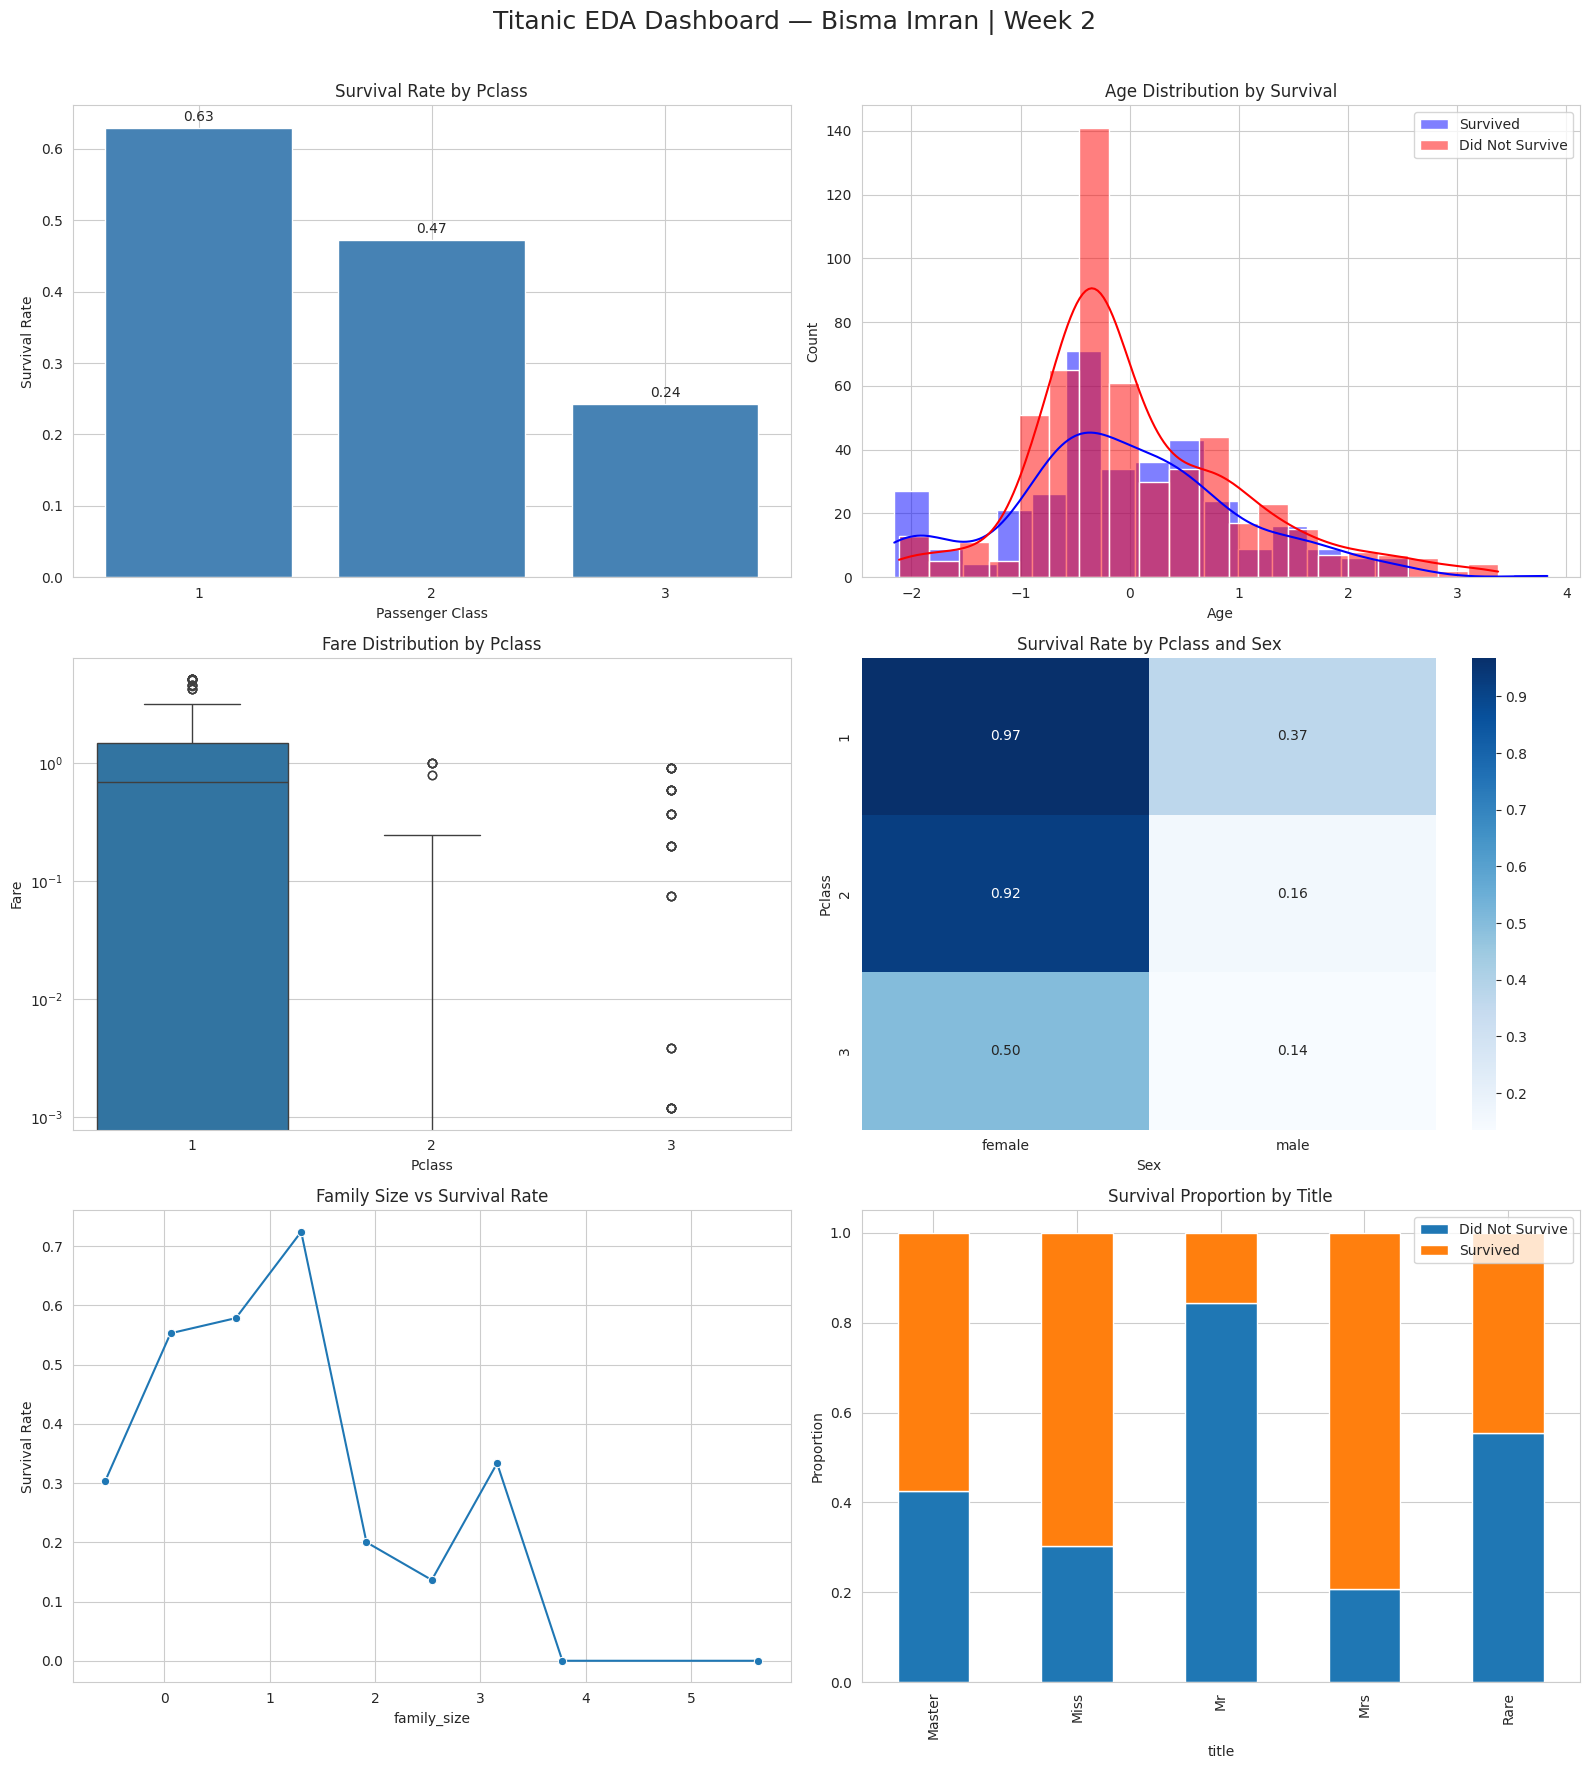

titanic_dashboard.png Saved Successfully


In [114]:
# Create Figure and Subplots

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(
    "Titanic EDA Dashboard — Bisma Imran | Week 2",
    fontsize=18
)

# Chart 1 — Survival Rate by Pclass

pclass_survival = df.groupby('Pclass')['Survived'].apply(lambda x: x.astype(int).mean())
axes[0, 0].bar(
    pclass_survival.index.astype(str),
    pclass_survival.values,
    color='steelblue'
)
axes[0, 0].set_title("Survival Rate by Pclass")
axes[0, 0].set_xlabel("Passenger Class")
axes[0, 0].set_ylabel("Survival Rate")

for i, value in enumerate(pclass_survival.values):

    axes[0, 0].text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha='center'
    )

# Chart 2 — Age Distribution by Survival

sns.histplot(
    data=df[df['Survived'].astype(int) == 1],
    x='Age',
    kde=True,
    color='blue',
    alpha=0.5,
    label='Survived',
    ax=axes[0, 1]
)
sns.histplot(
    data=df[df['Survived'].astype(int) == 0],
    x='Age',
    kde=True,
    color='red',
    alpha=0.5,
    label='Did Not Survive',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Age Distribution by Survival")
axes[0, 1].legend()

# Chart 3 — Fare Distribution by Pclass

sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare',
    ax=axes[1, 0]
)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Fare Distribution by Pclass")

# Chart 4 — Heatmap of Survival by Pclass × Sex

pivot_heatmap = pd.pivot_table(
    df,
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc=lambda x: x.astype(int).mean()
)
sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Survival Rate by Pclass and Sex")

# Chart 5 — Family Size vs Survival Rate

family_survival = df.groupby(
    'family_size'
)['Survived'].apply(lambda x: x.astype(int).mean()).reset_index()

sns.lineplot(
    data=family_survival,
    x='family_size',
    y='Survived',
    marker='o',
    ax=axes[2, 0]
)

axes[2, 0].set_title("Family Size vs Survival Rate")
axes[2, 0].set_ylabel("Survival Rate")

# Chart 6 — Survival Proportion by Title

title_survival = pd.crosstab(
    df['title'],
    df['Survived'].astype(int),
    normalize='index'
)
title_survival.plot(
    kind='bar',
    stacked=True,
    ax=axes[2, 1]
)
axes[2, 1].set_title("Survival Proportion by Title")
axes[2, 1].set_ylabel("Proportion")
axes[2, 1].legend(['Did Not Survive', 'Survived'])

# Adjust Layout

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Save Dashboard

fig.savefig(
    'titanic_dashboard.png',
    dpi=150
)
print("titanic_dashboard.png Saved Successfully")

#***STEP 16***

# Executive Summary

This project focused on analyzing the Titanic passenger dataset using Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn. The main objective was to explore the dataset, understand the factors that affected survival, clean and prepare the data, and create meaningful features that could later be used for machine learning models. The workflow included data inspection, handling missing values, outlier treatment, feature engineering, encoding, scaling, statistical analysis, and visualization.

Several important insights were discovered during the analysis. One of the strongest findings was that female passengers had a much higher survival rate than male passengers. Passenger class also played a major role, with first-class passengers surviving far more often than third-class passengers. Another important finding was that passengers paying higher fares generally had better survival chances, which suggests that economic status affected access to safety during the disaster. Family-related features and age groups also showed meaningful patterns connected to survival behavior.


# Data Quality Assessment

The dataset contained multiple data quality issues that needed to be handled before performing deeper analysis. The Age column had a large number of missing values, the Embarked column had a few missing entries, and the Cabin column contained mostly missing data. Some columns also required data type corrections because their stored types did not fully match their actual meaning.

Different strategies were used depending on the nature of the problem. Missing Age values were filled using the median age grouped by passenger class and gender because this approach preserves more realistic age patterns than using one global average. Missing Embarked values were filled with the mode because only two values were missing. Since the Cabin column had more than 75% missing values, a binary feature called has_cabin was created before dropping the original column. Outliers in the Fare column were capped instead of removed because those high values represented real first-class ticket prices. Categorical columns such as Survived, Pclass, Sex, and Embarked were also converted into more suitable data types for analysis.


# Feature Engineering Rationale

Several new features were created to improve the dataset and capture patterns that were not directly visible in the original columns. The family_size feature combined siblings, spouses, parents, children, and the passenger themselves into one value. This made it easier to analyze whether traveling alone or with family affected survival chances. The is_alone feature was also created to identify passengers who traveled completely alone.

The fare_per_person feature divided ticket fare by family size to better estimate the actual cost per traveler instead of using the total fare only. Passenger titles were extracted from names because titles can reveal information about social status, gender, or age. Rare titles were grouped into a single category to reduce unnecessary complexity. The age_group feature simplified ages into categories such as Child, Teen, Adult, and Senior, making patterns easier to interpret. The deck feature was extracted from cabin information because cabin location may relate to passenger class and access to lifeboats. Fare values were also grouped into fare_bin categories to simplify fare comparisons and analysis across passengers.


# Key Statistical Findings

The statistical analysis revealed several strong relationships between passenger characteristics and survival. The overall survival rate was around 38.4%, which means most passengers did not survive the disaster. Gender was one of the strongest predictors of survival. Female passengers had survival rates far above the overall average, while male passengers had much lower survival rates.

Passenger class also had a major impact. First-class passengers survived at much higher rates than second- and third-class passengers. This suggests that social and economic status affected access to lifeboats and safer areas of the ship. The fare analysis supported this observation because passengers paying higher fares generally had better survival outcomes.

The age group analysis showed that children often survived at higher rates than adults, which supports the historical “women and children first” evacuation policy. Family structure also affected survival patterns. Passengers traveling completely alone generally had lower survival rates compared to passengers traveling with small families. Correlation analysis confirmed that features such as sex_encoded, Pclass, Fare, family_size, and is_alone were among the most important variables connected to survival outcomes.


# Visualization Insights

The visualizations helped reveal trends and relationships more clearly than numerical summaries alone. The survival rate bar chart by passenger class showed a large gap between first-class and third-class survival rates. The age distribution chart showed noticeable differences between survivors and non-survivors across different age ranges.

The fare distribution box plots demonstrated that first-class passengers paid significantly higher fares than passengers in lower classes. The heatmap comparing passenger class and gender clearly highlighted that first-class female passengers had the highest survival rates, while third-class male passengers had the lowest. The family size line plot showed that passengers traveling with small families often had better survival outcomes than passengers traveling completely alone or in very large groups.

Among all visualizations, the heatmap of survival by Pclass and Sex was the most informative because it combined two of the strongest survival-related features in a single view. It clearly showed how gender and class together affected passenger survival.


# Feature Selection Recommendation

Based on the correlation analysis and overall survival patterns, the most suitable features for a future machine learning classifier would include sex_encoded, Pclass, Fare, family_size, is_alone, age_group_encoded, and fare_per_person.

The sex_encoded feature is highly important because gender showed one of the strongest relationships with survival. Passenger class and fare are useful because they represent economic and social status, which strongly influenced survival opportunities during the disaster. Family-related features help capture whether passengers traveled alone or with relatives, which also affected outcomes. Age group categories are valuable because children and adults showed different survival patterns. Fare per person provides additional information about passenger spending and travel conditions.

Using these features together would likely improve prediction performance while still keeping the model relatively understandable and efficient.


# Reflection

One of the most challenging parts of this project was handling missing values and deciding which preprocessing strategy was most appropriate for each column. It required understanding when to use filling methods, when to create additional features, and when dropping a column was the better choice.

Another challenging part was organizing the analysis step-by-step while making sure every transformation remained meaningful and connected to the original data. Working with groupby operations, pivot tables, and correlation analysis also helped improve understanding of how different features interact with each other.

The biggest surprise was how strongly gender and passenger class influenced survival outcomes. The differences became very clear during the visualization and statistical analysis steps. If this project were repeated, more time would be spent exploring additional feature engineering techniques and testing how different preprocessing decisions affect machine learning model performance in future stages.